### Лабораторная работа №9: Анализ возможностей нейросетевых технологий, используемых для повышения разрешения изображений

### Импорт библиотек и вспомогательные фунции

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple

def degrade_image_quality(image: np.ndarray, quality_percent: int) -> np.ndarray:
    """
    Искусственно ухудшает качество изображения путем JPEG-сжатия.
    quality_percent: от 0 (наихудшее) до 100 (наилучшее).
    """
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality_percent]
    _, encimg = cv2.imencode('.jpg', image, encode_param)
    decimg = cv2.imdecode(encimg, 1)
    return decimg

def apply_gamma_correction(image: np.ndarray, gamma: float) -> np.ndarray:
    """
    Реализует метод преобразования степенного закона: O(i,j) = I(i,j)^gamma.
    """
    # Нормализация значений пикселей к диапазону [0, 1]
    im_norm = image / 255.0
    # Применение гамма-коррекции
    im_gamma = cv2.pow(im_norm, gamma)
    # Возврат к диапазону [0, 255] и типу uint8
    return np.uint8(im_gamma * 255.0)

def apply_image_inverse(image: np.ndarray) -> np.ndarray:
    """
    Реализует метод Image Inverse: O(i,j) = 255 - I(i,j).
    """
    return 255 - image

def plot_results(images: List[np.ndarray], titles: List[str], figsize: Tuple[int, int] = (15, 5)):
    """
    Вспомогательная функция для отрисовки результатов экспериментов в ряд.
    """
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        # OpenCV читает в BGR, конвертируем в RGB для корректного отображения в matplotlib
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

### Проведение экспериментов

ЭКСПЕРИМЕНТ 1: Различные значения гамма-коррекции на одном изображении (Цветное)


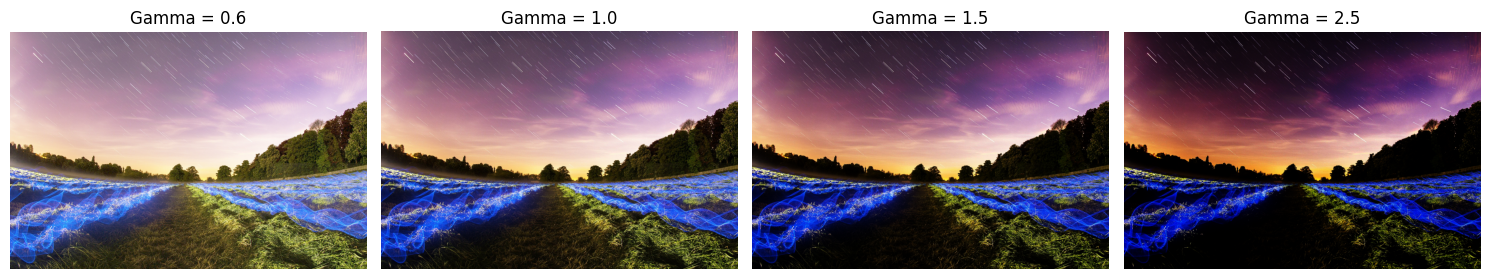


ЭКСПЕРИМЕНТ 2: Фиксированная гамма (gamma=0.6) на фото разного качества (Цветное)


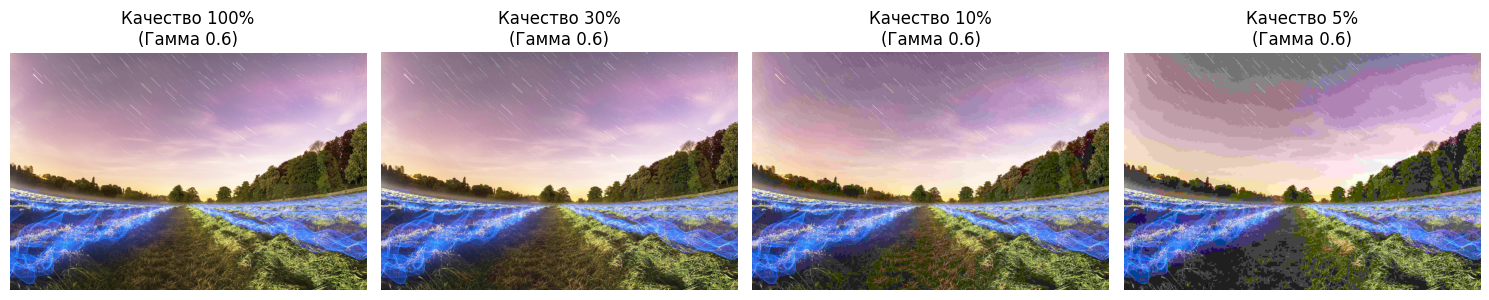


ЭКСПЕРИМЕНТ 3: Метод Image Inverse на исходных изображениях


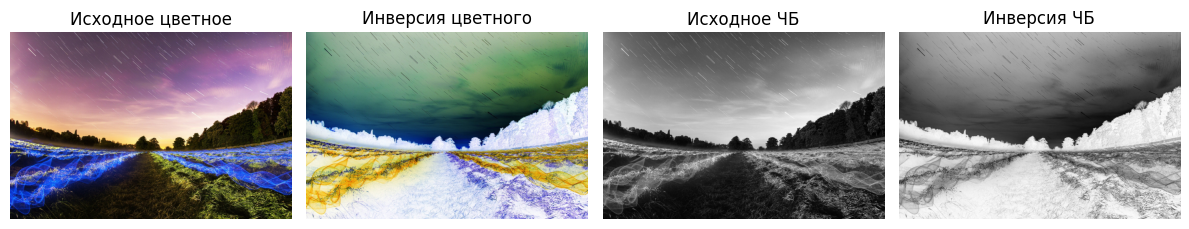


ЭКСПЕРИМЕНТ 4: Image Inverse на фото ухудшенного качества (ЧБ)


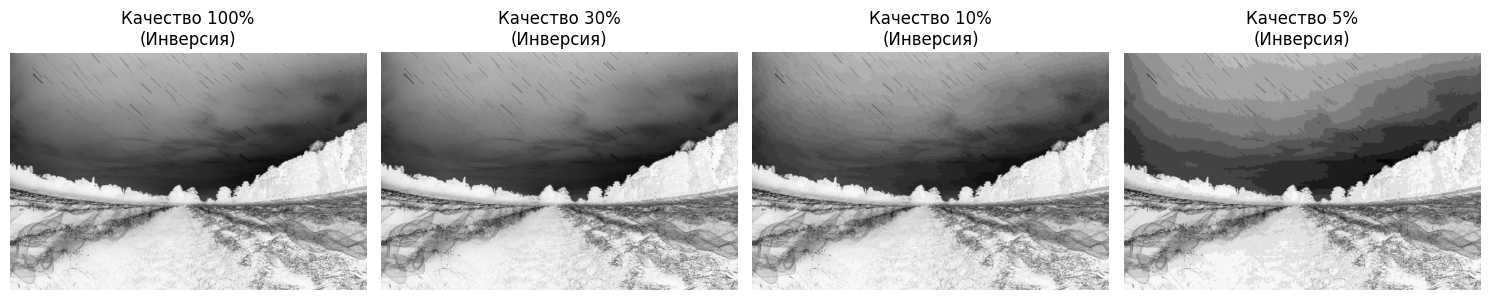

In [ ]:
# Загрузка исходных изображений
img_color = cv2.imread('color.jpg')
img_bw = cv2.imread('bw.jpg')

if img_color is None or img_bw is None:
    print("Ошибка: Изображения не найдены. Проверьте правильность путей")
else:
    print("ЭКСПЕРИМЕНТ 1: Различные значения гамма-коррекции на одном изображении (Цветное)")
    gammas = [0.6, 1.0, 1.5, 2.5]
    gamma_results = [apply_gamma_correction(img_color, g) for g in gammas]
    gamma_titles = [f"Gamma = {g}" for g in gammas]
    plot_results(gamma_results, gamma_titles)

    print("\nЭКСПЕРИМЕНТ 2: Фиксированная гамма (gamma=0.6) на фото разного качества (Цветное)")
    qualities = [100, 30, 10, 5]
    degraded_images = [degrade_image_quality(img_color, q) for q in qualities]
    # Применяем гамма-коррекцию к ухудшенным изображениям
    gamma_on_degraded = [apply_gamma_correction(img, 0.6) for img in degraded_images]
    quality_titles = [f"Качество {q}%\n(Гамма 0.6)" for q in qualities]
    plot_results(gamma_on_degraded, quality_titles)

    print("\nЭКСПЕРИМЕНТ 3: Метод Image Inverse на исходных изображениях")
    inv_color = apply_image_inverse(img_color)
    inv_bw = apply_image_inverse(img_bw)
    plot_results([img_color, inv_color, img_bw, inv_bw],
                 ["Исходное цветное", "Инверсия цветного", "Исходное ЧБ", "Инверсия ЧБ"],
                 figsize=(12, 6))

    print("\nЭКСПЕРИМЕНТ 4: Image Inverse на фото ухудшенного качества (ЧБ)")
    degraded_bw_images = [degrade_image_quality(img_bw, q) for q in qualities]
    inv_on_degraded_bw = [apply_image_inverse(img) for img in degraded_bw_images]
    inv_quality_titles = [f"Качество {q}%\n(Инверсия)" for q in qualities]
    plot_results(inv_on_degraded_bw, inv_quality_titles)